# PubMed RCT Classification using LSTM
This notebook demonstrates a complete pipeline to classify medical abstract sentences using the PubMed RCT dataset.

In [1]:
!pip install datasets -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks

## 1. Load and Explore Dataset

In [7]:
import os
if not os.path.exists("pubmed-rct"):
    !git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git

def preprocess_text_with_line_numbers(filename):
    input_lines = open(filename, "r").readlines()
    abstract_samples = []
    abstract_lines = ""
    for line in input_lines:
        if line.startswith("###"):
            abstract_lines = ""
        elif line.isspace():
            abstract_line_split = abstract_lines.splitlines()
            for abstract_line in abstract_line_split:
                line_data = {}
                target_text_split = abstract_line.split("\t")
                line_data["target"] = target_text_split[0]
                line_data["text"] = target_text_split[1].lower()
                abstract_samples.append(line_data)
        else:
            abstract_lines += line
    return abstract_samples

train_samples = preprocess_text_with_line_numbers("pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt")
test_samples = preprocess_text_with_line_numbers("pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt")

train_df = pd.DataFrame(train_samples)
test_df = pd.DataFrame(test_samples)

print(f"Total training samples: {len(train_df)}")
display(train_df.head())
print("\nUnique Labels:", train_df["target"].unique())

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 32.71 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Total training samples: 180040


,target,text
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...
1,METHODS,a total of @ patients with primary knee oa wer...
2,METHODS,outcome measures included pain reduction and i...
3,METHODS,pain was assessed using the visual analog pain...
4,METHODS,secondary outcome measures included the wester...



Unique Labels: ['OBJECTIVE' 'METHODS' 'RESULTS' 'CONCLUSIONS' 'BACKGROUND']


## 2. Preprocessing

In [9]:
MAX_VOCAB = 20000
MAX_LEN = 100

tokenizer = layers.TextVectorization(max_tokens=MAX_VOCAB, output_sequence_length=MAX_LEN)
tokenizer.adapt(train_df['text'].values)

encoder = LabelEncoder()
y_train = encoder.fit_transform(train_df['target'])
y_test = encoder.transform(test_df['target'])
num_classes = len(encoder.classes_)

def prepare_data(df):
    return tokenizer(df['text'].values)

X_train = prepare_data(train_df)
X_test = prepare_data(test_df)

## 3. Model Building & Comparison

In [10]:
def build_lstm_model(optimizer="adam", learning_rate=0.001, units=64):
    model = tf.keras.Sequential([
        layers.Input(shape=(MAX_LEN,)),
        layers.Embedding(MAX_VOCAB, 128),
        layers.LSTM(units, kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    if optimizer.lower() == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer.lower() == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

results = {}
for opt_name in ["adam", "sgd", "rmsprop"]:
    print(f"\nTraining with {opt_name}...")
    temp_model = build_lstm_model(optimizer=opt_name)
    history = temp_model.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=1)
    results[opt_name] = history.history["val_accuracy"][-1]
    print(f"{opt_name} Val Accuracy: {results[opt_name]:.4f}")


Training with adam...
Epoch 1/3
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.3244 - loss: 1.5261 - val_accuracy: 0.3255 - val_loss: 1.4715
Epoch 2/3
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3277 - loss: 1.4703 - val_accuracy: 0.3255 - val_loss: 1.4716
Epoch 3/3
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3287 - loss: 1.4695 - val_accuracy: 0.3255 - val_loss: 1.4717
adam Val Accuracy: 0.3255

Training with sgd...
Epoch 1/3
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3180 - loss: 3.2021 - val_accuracy: 0.3233 - val_loss: 3.1204
Epoch 2/3
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3257 - loss: 3.0710 - val_accuracy: 0.3255 - val_loss: 3.0248
Epoch 3/3
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3272 - loss: 2.9869 - val_accuracy: 0.3255 - val_loss: 2.9457
sgd Val Accuracy: 0.3255

Training with rmsprop...
Epoch 1/3
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3266 - loss: 1.5169 - val_

## 4. Final Training with Hyperparameter Tuning & Visualization

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,692,229 (10.27 MB)

 Trainable params: 2,692,229 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.3274 - loss: 1.4963 - val_accuracy: 0.3255 - val_loss: 1.4720
Epoch 2/10
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.3288 - loss: 1.4699 - val_accuracy: 0.3255 - val_loss: 1.4714
Epoch 3/10
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.3279 - loss: 1.4696 - val_accuracy: 0.3233 - val_loss: 1.4725
Epoch 4/10
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.3280 - loss: 1.4694 - val_accuracy: 0.3255 - val_loss: 1.4715
Epoch 5/10
2532/2532 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.3286 - loss: 1.4690 - val_accuracy: 0.3255 - val_loss: 1.4719


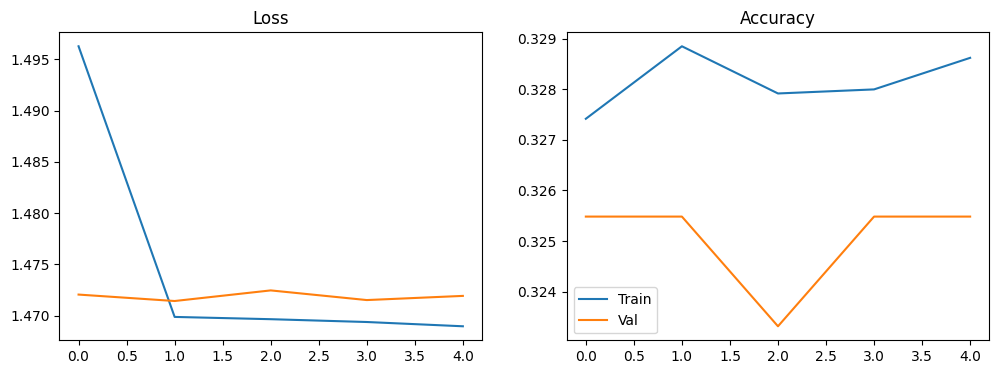

In [11]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Final Model using Adam, 128 units, batch 64
final_model = build_lstm_model(optimizer='adam', learning_rate=0.001, units=128)
final_model.summary()

history = final_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Val')
ax1.set_title('Loss')
ax2.plot(history.history['accuracy'], label='Train')
ax2.plot(history.history['val_accuracy'], label='Val')
ax2.set_title('Accuracy')
plt.legend()
plt.show()

## 5. Evaluation and Saving

942/942 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Classification Report:
              precision    recall  f1-score   support

  BACKGROUND       0.00      0.00      0.00      3621
 CONCLUSIONS       0.00      0.00      0.00      4571
     METHODS       0.33      1.00      0.49      9897
   OBJECTIVE       0.00      0.00      0.00      2333
     RESULTS       0.00      0.00      0.00      9713

    accuracy                           0.33     30135
   macro avg       0.07      0.20      0.10     30135
weighted avg       0.11      0.33      0.16     30135



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


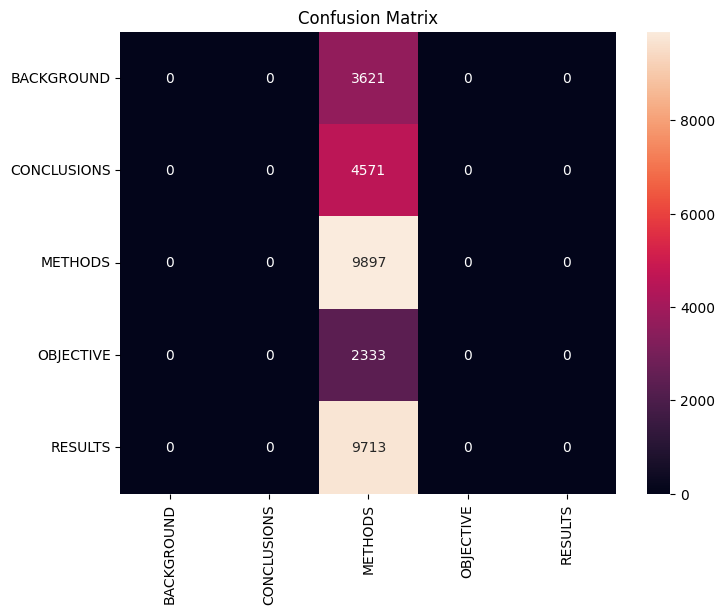

Model saved as PubMed_RCT_lstm_model.h5


In [12]:
y_pred = np.argmax(final_model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.show()

final_model.save('PubMed_RCT_lstm_model.h5')
print("Model saved as PubMed_RCT_lstm_model.h5")